# Imports

In [1]:
import os
import joblib
import json
from pathlib import Path

In [2]:
import numpy as np
import pandas as pd

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

In [4]:
from model_testing import ModelTesting

In [5]:
import warnings
warnings.filterwarnings("ignore")

In [6]:
data_store=Path("./Prepared_Data_Store")

# Loading Models

In [7]:
model1=joblib.load(os.path.join(data_store,"model1.pkl"))

In [8]:
model4=joblib.load(os.path.join(data_store,"model4.pkl"))

In [9]:
model2=joblib.load(os.path.join(data_store,"model2.pkl"))

In [10]:
model3=joblib.load(os.path.join(data_store,"model3.pkl"))

In [11]:
model8=joblib.load(os.path.join(data_store,"model8.pkl"))

# Loading Model Predictions

In [12]:
model1_predictions=pd.read_csv(
    os.path.join(data_store,"model1_predictions.csv"),
    parse_dates=["date"],
    index_col=["date","ticker"]
)

model4_predictions=pd.read_csv(
    os.path.join(data_store,"model4_predictions.csv"),
    parse_dates=["date"],
    index_col=["date","ticker"]
)

model2_predictions=pd.read_csv(
    os.path.join(data_store,"model2_predictions.csv"),
    parse_dates=["date"],
    index_col=["date","ticker"]
)

model3_predictions=pd.read_csv(
    os.path.join(data_store,"model3_predictions.csv"),
    parse_dates=["date"],
    index_col=["date","ticker"]
)

model8_predictions=pd.read_csv(
    os.path.join(data_store,"model8_predictions.csv"),
    parse_dates=["date"],
    index_col=["date","ticker"]
)

# Loading Model Scores

In [13]:
model1_scores=pd.read_csv(
    os.path.join(data_store,"model1_scores.csv"),
    parse_dates=["date"],
    index_col=["date"]
    
)

model4_scores=pd.read_csv(
    os.path.join(data_store,"model4_scores.csv"),
    parse_dates=["date"],
    index_col=["date"]
    
)

model2_scores=pd.read_csv(
    os.path.join(data_store,"model2_scores.csv"),
    parse_dates=["date"],
    index_col=["date"]
    
)

model3_scores=pd.read_csv(
    os.path.join(data_store,"model3_scores.csv"),
    parse_dates=["date"],
    index_col=["date"]
    
)

model8_scores=pd.read_csv(
    os.path.join(data_store,"model8_scores.csv"),
    parse_dates=["date"],
    index_col=["date"]
    
)

# Training Plots

In [14]:
models=["Model-1","Model-4","Model-2","Model-3","Model-8"]

## Prediction VS Actual Scatter Plot

In [15]:
predictions=[
    model1_predictions,
    model4_predictions,
    model2_predictions,
    model3_predictions,
    model8_predictions,
]

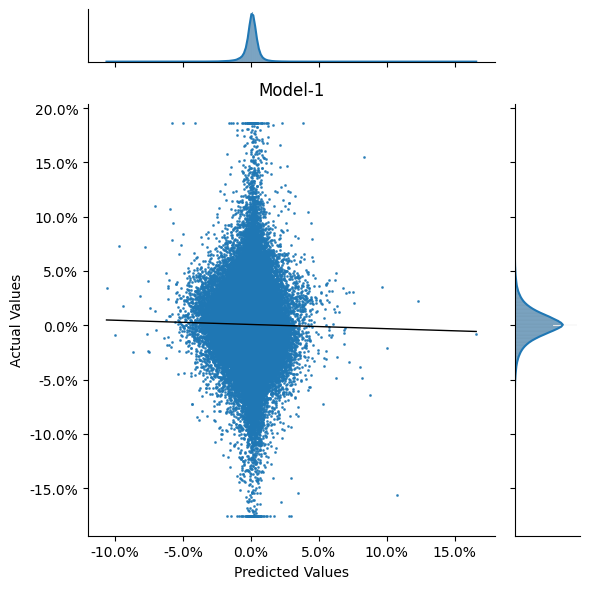

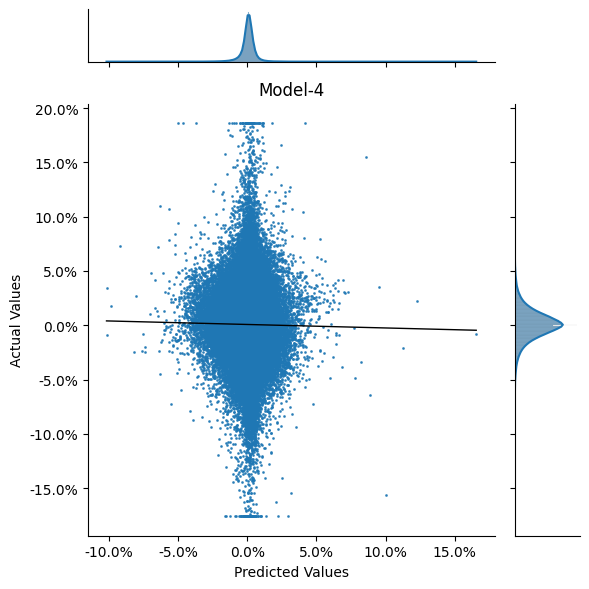

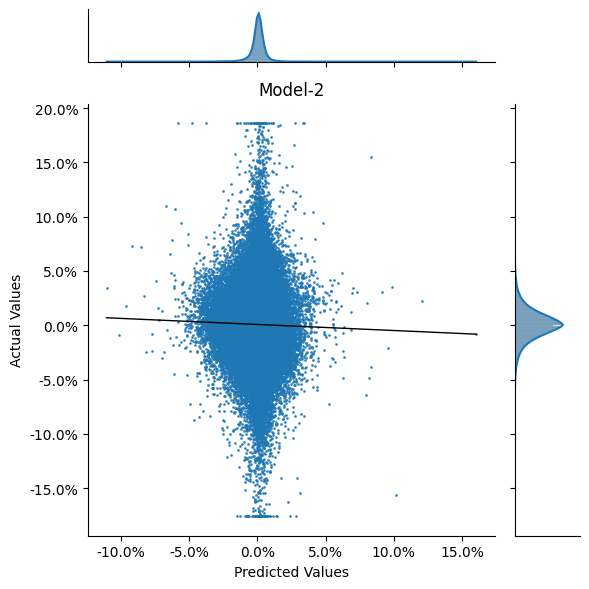

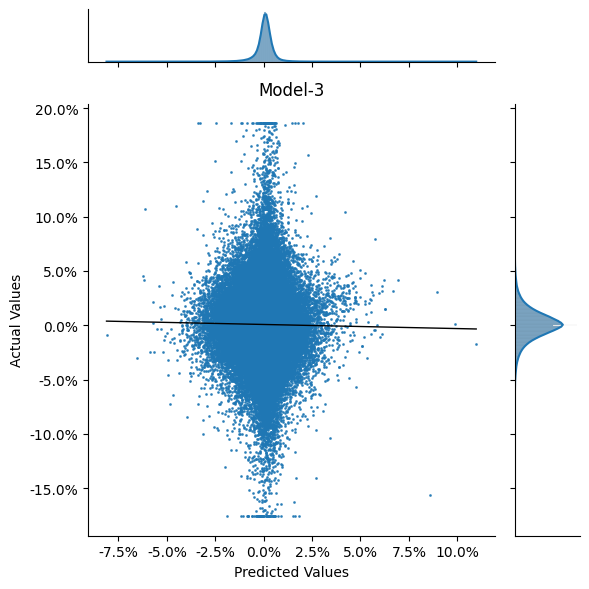

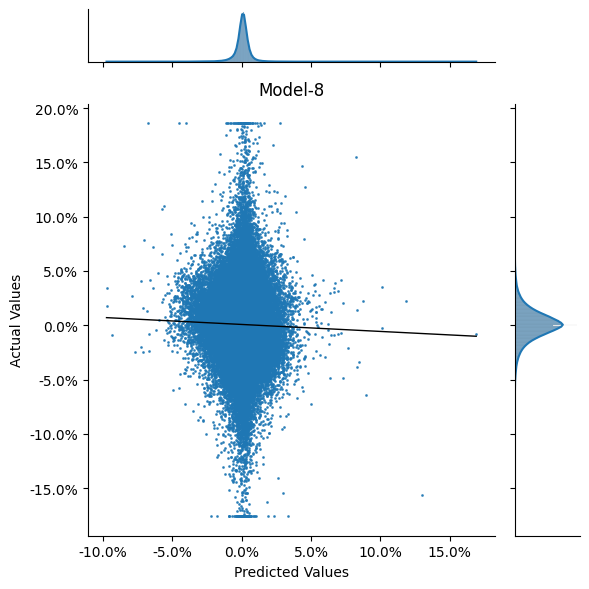

In [16]:
for model,pred in zip(models,predictions):
    j=sns.jointplot(
        x="ypreds",
        y="yreal",
        ci=None,
        robust=True,
        line_kws={"lw":1.0,"color":"k"},
        scatter_kws={"s":1.0},
        kind="reg",
        data=pred
    )

    j.ax_joint.yaxis.set_major_formatter(
        FuncFormatter(lambda y,_:'{:.1%}'.format(y))
    )

    j.ax_joint.xaxis.set_major_formatter(
        FuncFormatter(lambda x,_:'{:.1%}'.format(x))
    )

    j.ax_joint.set_xlabel("Predicted Values")
    j.ax_joint.set_ylabel("Actual Values")
    j.ax_joint.set_title(f"{model}")

    plt.tight_layout()
    sns.despine()
    plt.show()

## Daily IC Distribution

In [17]:
scores=[
    model1_scores,
    model4_scores,
    model2_scores,
    model3_scores,
    model8_scores,
]

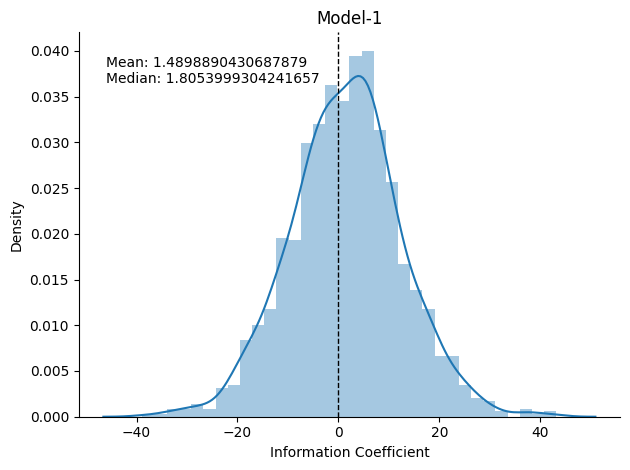

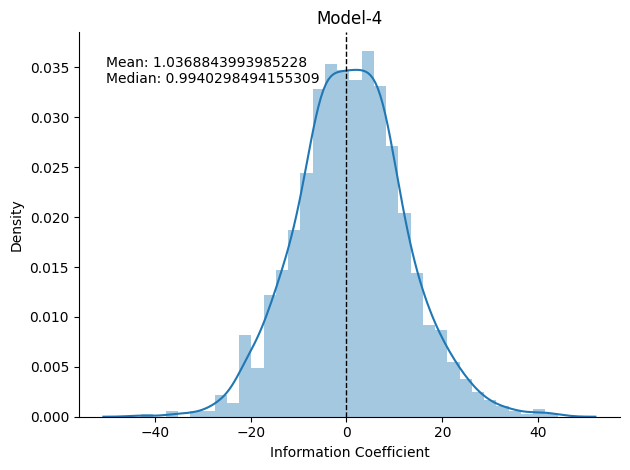

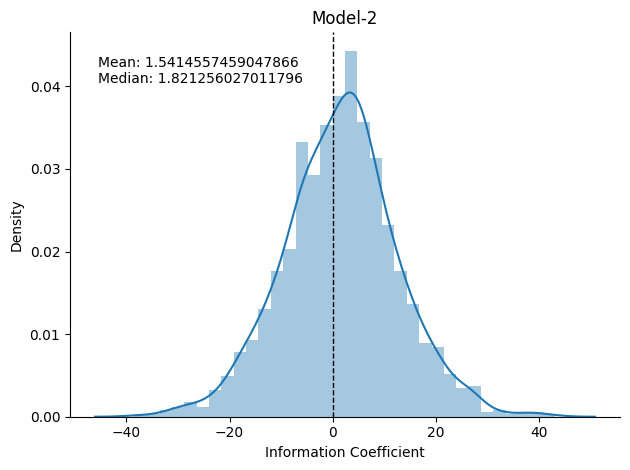

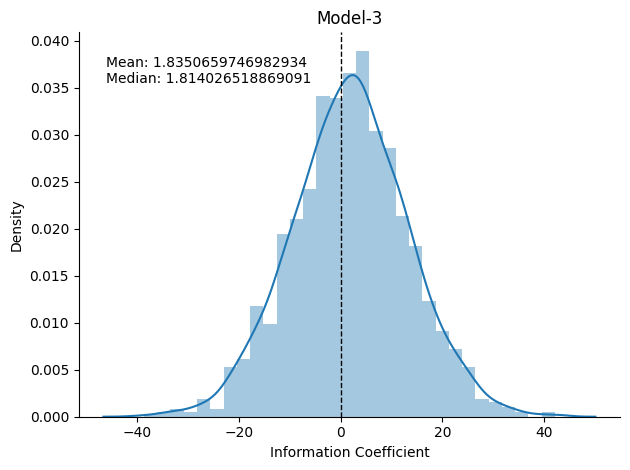

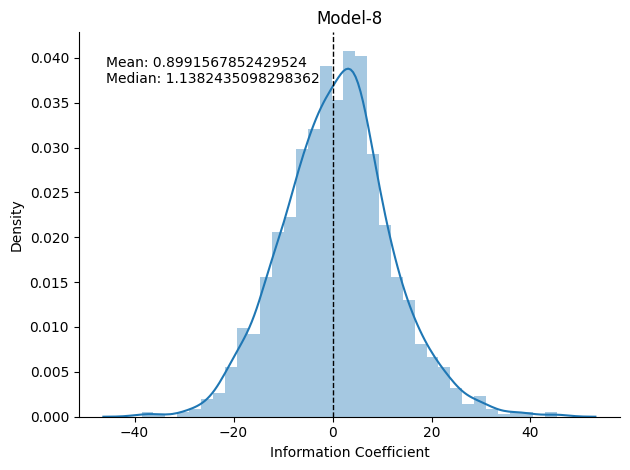

In [18]:
for model,score in zip(models,scores):
    ax=sns.distplot(score.ic)
    ax.axvline(0,lw=1.0,ls="--",c="k")

    ic_mean=score.ic.mean()
    ic_median=score.ic.median()

    ax.text(
        x=.05,
        y=.9,
        s=f"Mean: {ic_mean}\nMedian: {ic_median}",
        horizontalalignment="left",
        verticalalignment="center",
        transform=ax.transAxes
    )

    ax.set_xlabel("Information Coefficient")
    ax.set_title(f"{model}")

    plt.tight_layout()
    sns.despine()
    plt.show()

## Rolling Daily IC

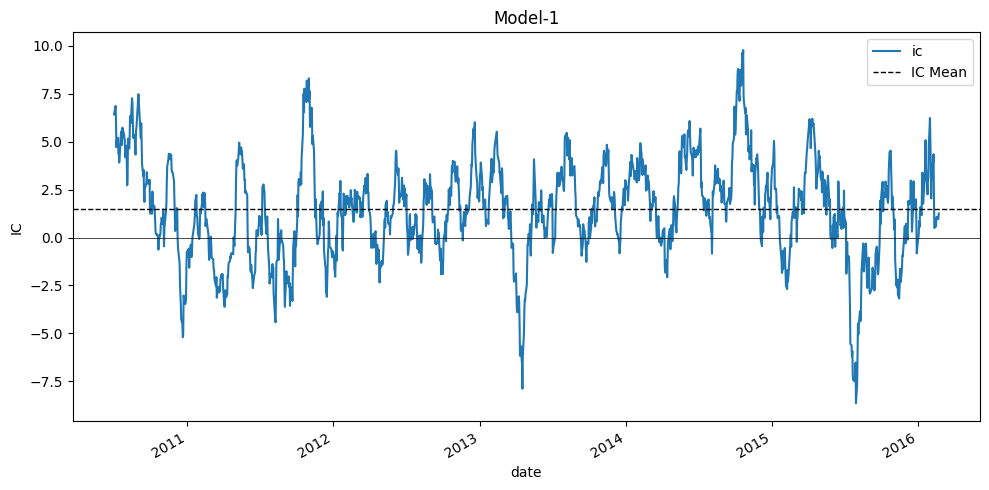

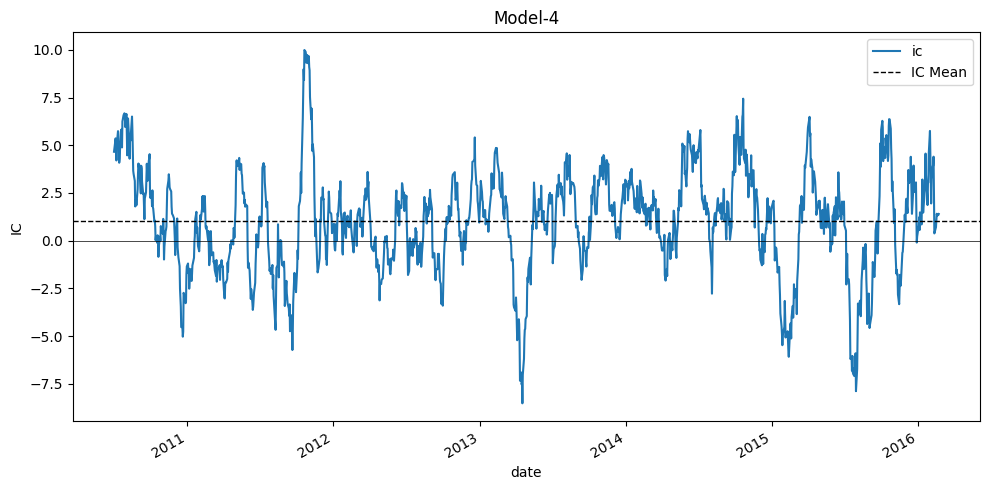

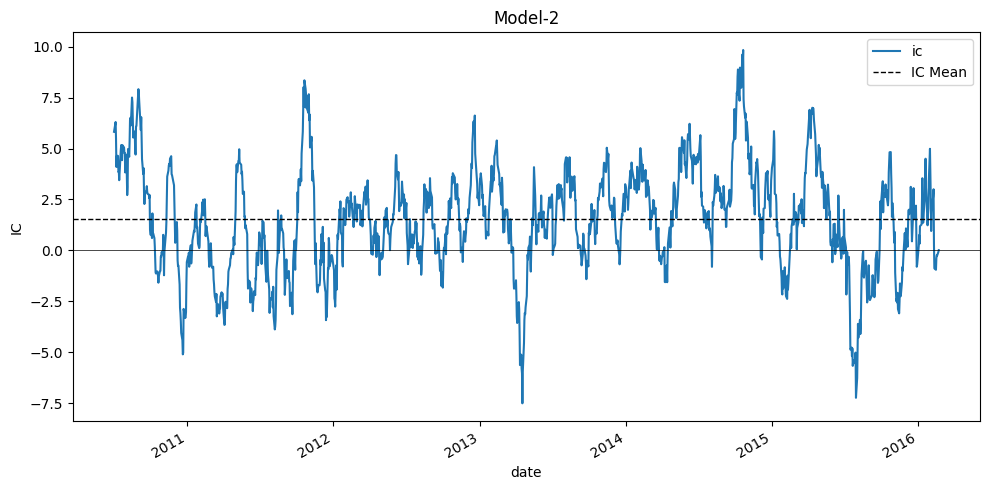

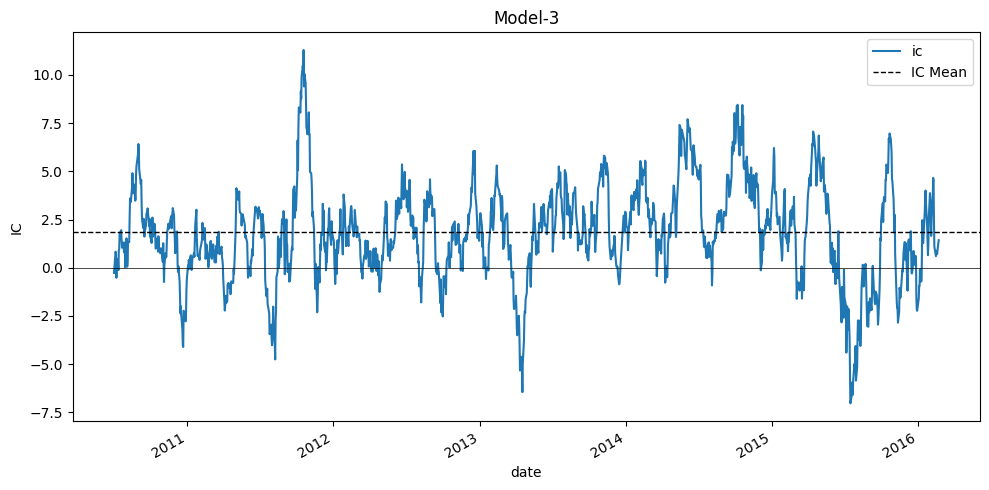

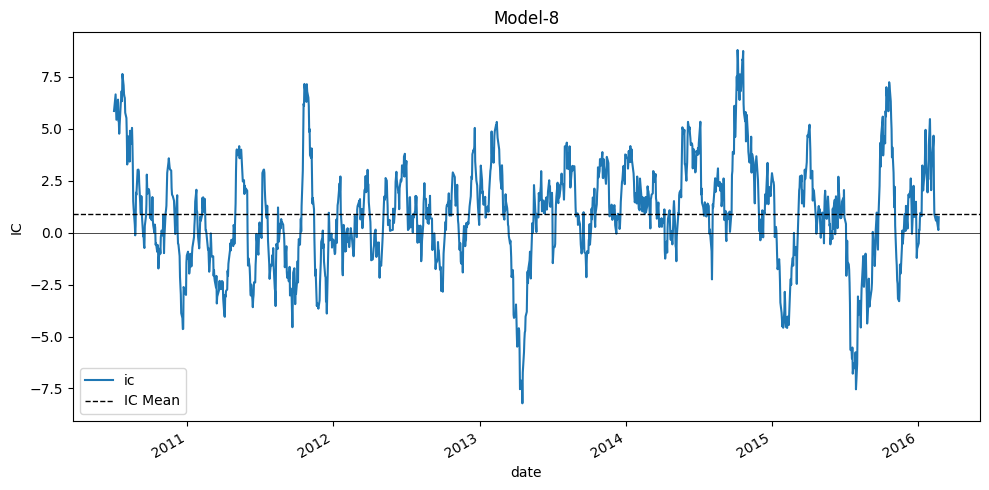

In [19]:
for model,score in zip(models,scores):
    score[["ic"]].rolling(21).mean().plot(figsize=(10,5))
    ic_mean=score.ic.mean(axis=0)
    plt.axhline(0,lw=.5,ls="-",c="k")
    plt.axhline(ic_mean,lw=1.0,ls="--",c="k",label="IC Mean")
    plt.legend()
    plt.ylabel("IC")
    plt.title(f"{model}")
    
    plt.tight_layout()
    plt.show()

## Rolling RMSE

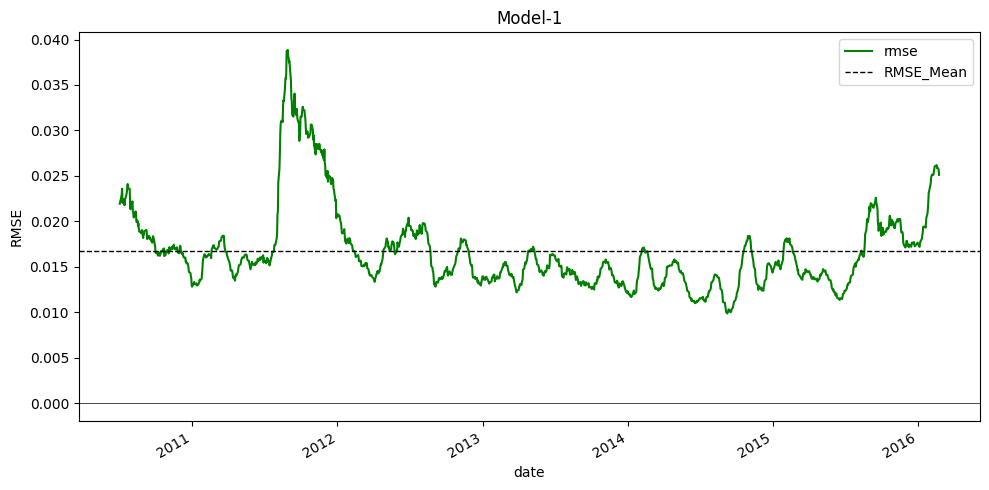

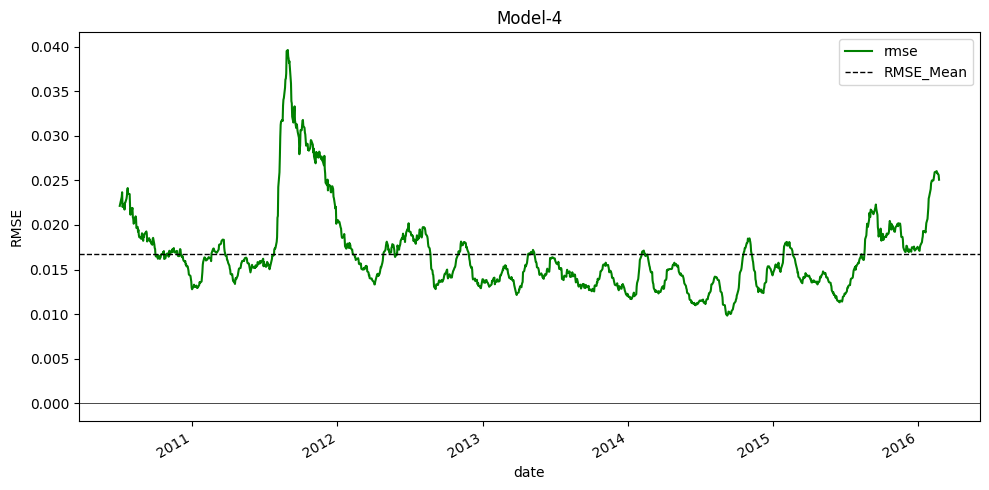

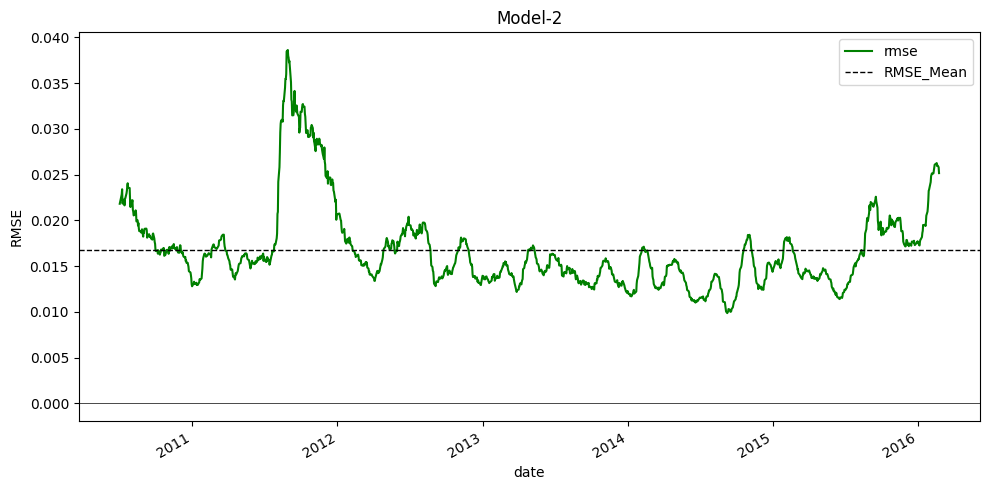

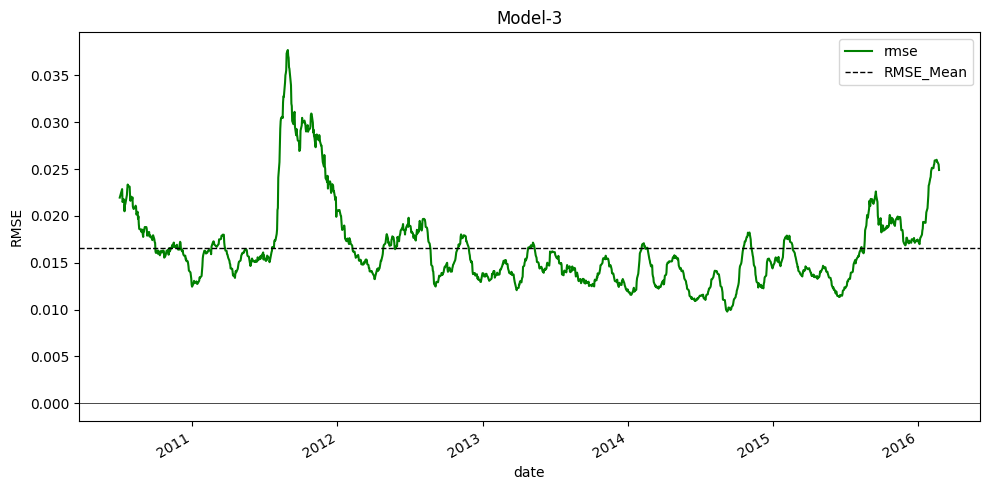

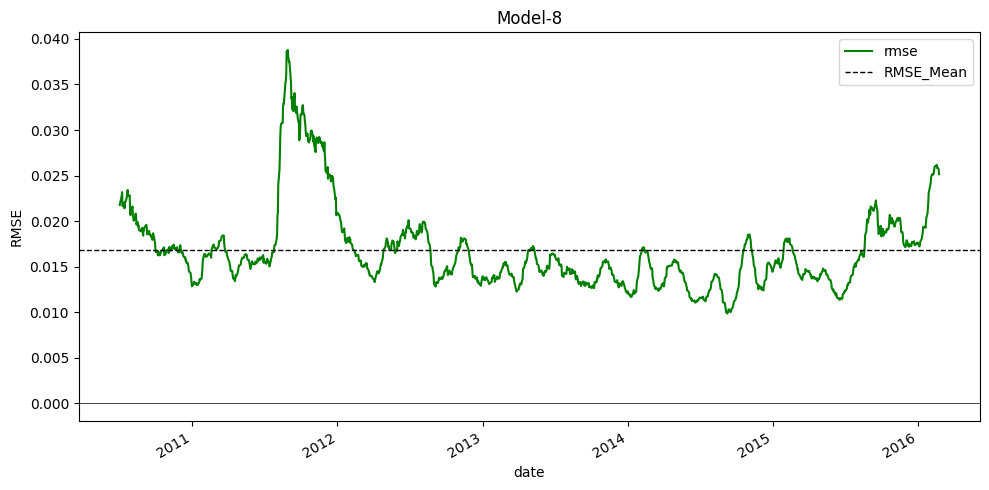

In [20]:
for model,score in zip(models,scores):
    score[["rmse"]].rolling(21).mean().plot(figsize=(10,5),style=["g"])

    rmse_mean=score.rmse.mean(axis=0)
    plt.axhline(0,lw=.5,ls="-",c="k")
    plt.axhline(rmse_mean,lw=1.0,ls="--",c="k",label="RMSE_Mean")
    plt.legend()
    plt.ylabel("RMSE")
    plt.title(f"{model}")

    plt.tight_layout()
    plt.show()

# Testing Models

## Loading Testing Data

In [21]:
test_data=pd.read_csv(
    os.path.join(data_store,"test_data.csv"),
    parse_dates=["date"],
    index_col=["date","ticker"]
)

In [22]:
test_Y=test_data.filter(like="forward_returns")

In [23]:
test_X=test_data.drop(test_Y.columns,axis=1,inplace=False)

## Preparing Testing Data

In [24]:
test_X

open        high         low       close     volume  \
date       ticker                                                              
2016-02-24 A        36.012987   36.848213   35.836115   36.828561  1454952.0   
           ACGL     67.690000   68.950000   67.300000   68.790000   341478.0   
           ACN      94.798058   95.730182   94.096562   95.662916  2567838.0   
           ADI      48.808218   50.013954   48.325923   49.975371  2690936.0   
           ADM      31.839203   32.180846   31.393170   32.123906  3769583.0   
...                       ...         ...         ...         ...        ...   
2017-11-29 XEL      51.180000   51.480000   50.850000   51.260000  2311537.0   
           XOM      81.650000   82.310000   81.480000   82.270000  9475070.0   
           YUM      81.290000   82.120000   81.200000   81.810000  1658544.0   
           ZBH     115.500000  116.740000  115.000000  116.520000  1749712.0   
           ZBRA    111.630000  112.390000  108.575000  109.430000   318334.0   

                   dollar_volume  dollar_volume_7d  dollar_volume_15d  \
date       ticker                                                       
2016-02-24 A        5.358379e+07      9.158753e+07       1.064257e+08   
           ACGL     2.349027e+07      2.759548e+07       3.156245e+07   
           ACN      2.456469e+08      2.791125e+08       3.629054e+08   
           ADI      1.344805e+08      1.387501e+08       1.309856e+08   
           ADM      1.210937e+08      1.281672e+08       1.582446e+08   
...                          ...               ...                ...   
2017-11-29 XEL      1.184894e+08      1.072401e+08       1.381043e+08   
           XOM      7.795140e+08      6.577386e+08       7.044767e+08   
           YUM      1.356855e+08      1.058911e+08       1.232016e+08   
           ZBH      2.038764e+08      1.181175e+08       1.283747e+08   
           ZBRA     3.483529e+07      2.512778e+07       3.858277e+07   

                   dollar_volume_21d  dollar_volume_rank  ...  max_price_7d  \
date       ticker                                         ...                 
2016-02-24 A            1.004817e+08               272.0  ...     37.369001   
           ACGL         3.263230e+07               357.0  ...     68.790000   
           ACN          3.588292e+08                70.0  ...     96.431678   
           ADI          1.330788e+08               226.0  ...     50.453787   
           ADM          1.753127e+08               172.0  ...     32.171356   
...                              ...                 ...  ...           ...   
2017-11-29 XEL          1.471875e+08               187.0  ...     51.260000   
           XOM          6.980541e+08                19.0  ...     82.270000   
           YUM          1.427005e+08               192.0  ...     81.810000   
           ZBH          1.856724e+08               151.0  ...    116.520000   
           ZBRA         3.879641e+07               357.0  ...    109.430000   

                   max_price_15d  max_price_21d        rsi  bb_lower  \
date       ticker                                                      
2016-02-24 A           37.369001      37.369001  50.918459  0.064537   
           ACGL        68.880000      68.880000  55.225311  0.045749   
           ACN         98.718748     102.130132  49.939781  0.075281   
           ADI         50.453787      51.535008  52.717991  0.071142   
           ADM         32.198120      33.335631  51.870811  0.060524   
...                          ...            ...        ...       ...   
2017-11-29 XEL         51.800000      51.800000  65.290904  0.042928   
           XOM         83.970000      83.970000  53.042117  0.030274   
           YUM         81.810000      81.810000  70.977637  0.073931   
           ZBH        116.520000     121.620000  56.797228  0.077946   
           ZBRA       109.430000     115.990000  51.484961  0.065231   

                   bb_upper  avg_true_range      macd  macd_hist  mac

In [97]:
test_Y.to_frame("yreal").to_csv(
    os.path.join(data_store,"test_Y.csv"),
    index=True
)

### Standardizing Testing Data

#### Loading Feature's Mean and Standard Deviation Per Ticker

In [25]:
feature_mean_per_ticker=pd.read_csv(
    os.path.join(data_store,"training_feature_mean_per_ticker.csv"),
    index_col=["ticker"]
)

In [26]:
feature_mean_per_ticker

,open,high,low,close,volume,dollar_volume,dollar_volume_7d,dollar_volume_15d,dollar_volume_21d,dollar_volume_rank,...,max_price_7d,max_price_15d,max_price_21d,rsi,bb_lower,bb_upper,avg_true_range,macd,macd_hist,macd_signal
ticker,,,,,,,,,,,,,,,,,,,,,
A,31.761607,32.098822,31.418999,31.772302,3.153154e+06,9.609850e+07,9.609283e+07,9.602089e+07,9.597259e+07,196.439153,...,32.483078,32.914676,33.156601,52.522852,0.055558,0.045927,0.738689,0.075407,-0.000626,0.076033
ACGL,46.852395,47.185698,46.517034,46.872957,6.492017e+05,2.742384e+07,2.747375e+07,2.748114e+07,2.748817e+07,327.177249,...,47.365357,47.641319,47.787986,54.917605,0.034607,0.021725,0.681710,0.203490,-0.000065,0.203555
ACN,63.816940,64.369762,63.327148,63.883219,3.521674e+06,2.107092e+08,2.104231e+08,2.097934e+08,2.092878e+08,91.358466,...,64.908413,65.502320,65.803829,54.376523,0.047681,0.034459,1.131341,0.282082,-0.001481,0.283563
ADI,39.724366,40.108551,39.314379,39.732832,2.841122e+06,1.062885e+08,1.063801e+08,1.063465e+08,1.063091e+08,182.197090,...,40.511909,40.972520,41.209762,52.678322,0.050065,0.039490,0.849038,0.120667,0.000746,0.119921
ADM,32.160290,32.453966,31.857967,32.162663,4.735319e+06,1.454981e+08,1.454681e+08,1.454705e+08,1.453973e+08,132.720899,...,32.786470,33.221132,33.474346,51.891968,0.048472,0.043116,0.637194,0.031238,-0.000142,0.031380
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
XEL,24.338827,24.512508,24.161445,24.350561,2.896462e+06,7.186534e+07,7.168580e+07,7.137921e+07,7.109879e+07,242.337963,...,24.636189,24.797932,24.878291,54.112707,0.034076,0.022853,0.362476,0.093862,0.002496,0.091366
XOM,72.118834,72.649226,71.582391,72.151562,1.675708e+07,1.150553e+09,1.151032e+09,1.151424e+09,1.151834e+09,5.730820,...,73.193044,73.801565,74.151031,52.001850,0.036866,0.031226,1.155466,0.092559,0.005729,0.086831
YUM,42.697443,43.088775,42.314695,42.713363,3.803392e+06,1.603624e+08,1.601049e+08,1.598293e+08,1.594167e+08,123.971561,...,43.494469,43.971826,44.231132,53.738303,0.048590,0.036935,0.848032,0.126126,0.000564,0.125563


In [27]:
feature_std_dev_per_ticker=pd.read_csv(
    os.path.join(data_store,"training_features_std_dev_per_ticker.csv"),
    index_col=["ticker"]
)

In [28]:
feature_std_dev_per_ticker

,open,high,low,close,volume,dollar_volume,dollar_volume_7d,dollar_volume_15d,dollar_volume_21d,dollar_volume_rank,...,max_price_7d,max_price_15d,max_price_21d,rsi,bb_lower,bb_upper,avg_true_range,macd,macd_hist,macd_signal
ticker,,,,,,,,,,,,,,,,,,,,,
A,6.627588,6.631424,6.621240,6.624655,1.690641e+06,5.008561e+07,3.060473e+07,2.472940e+07,2.272651e+07,39.987460,...,6.592364,6.585149,6.574316,11.193668,0.040954,0.044219,0.196175,0.556008,0.167344,0.523029
ACGL,14.454533,14.534470,14.350339,14.438456,4.580173e+05,1.652756e+07,1.030937e+07,8.466723e+06,7.696145e+06,24.342533,...,14.577317,14.717828,14.809503,11.015430,0.026406,0.020201,0.259679,0.471100,0.147446,0.441272
ACN,19.451954,19.566973,19.333580,19.455220,3.253988e+06,1.682005e+08,1.031410e+08,8.465186e+07,7.626701e+07,21.629693,...,19.661922,19.778628,19.804820,11.379703,0.034936,0.033478,0.369037,0.787987,0.281577,0.719778
ADI,10.625029,10.711851,10.535449,10.613414,1.610722e+06,5.718737e+07,3.722381e+07,3.152537e+07,2.928901e+07,33.778381,...,10.815277,10.975200,11.073298,10.635897,0.036313,0.033860,0.298753,0.603565,0.195544,0.563633
ADM,8.160282,8.218346,8.115362,8.164952,2.178883e+06,6.134645e+07,4.181126e+07,3.496428e+07,3.197204e+07,25.982382,...,8.255776,8.320445,8.362491,12.947720,0.036586,0.041438,0.179521,0.563361,0.174504,0.528425
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
XEL,5.416789,5.476077,5.361063,5.426330,1.466048e+06,4.169345e+07,3.271352e+07,2.980355e+07,2.826195e+07,32.438592,...,5.515409,5.569723,5.599591,10.117232,0.023402,0.022304,0.132515,0.228193,0.078364,0.209055
XOM,11.011562,11.032396,10.989985,11.006418,8.296004e+06,4.318740e+08,3.137984e+08,2.735342e+08,2.590495e+08,1.910202,...,11.056367,11.096843,11.106067,11.691865,0.028515,0.029486,0.332944,0.806283,0.259969,0.752160
YUM,9.718148,9.788391,9.640609,9.713352,2.349841e+06,1.098374e+08,7.225992e+07,6.042086e+07,5.480053e+07,31.711804,...,9.945710,10.124004,10.222612,11.823836,0.033768,0.034877,0.283595,0.610270,0.199790,0.568331


In [29]:
tickers=list(test_data.index.get_level_values("ticker").unique())

In [30]:
for ticker in tickers:
    test_X[test_X.index.get_level_values("ticker")==ticker]=(
        (test_X[test_X.index.get_level_values("ticker")==ticker]-feature_mean_per_ticker.loc[ticker])/
        feature_std_dev_per_ticker.loc[ticker]
    )

In [31]:
test_X

open      high       low     close    volume  \
date       ticker                                                     
2016-02-24 A       0.641467  0.716195  0.667113  0.763249 -1.004473   
           ACGL    1.441597  1.497427  1.448256  1.517963 -0.671860   
           ACN     1.592699  1.602722  1.591501  1.633479 -0.293128   
           ADI     0.854948  0.924714  0.855355  0.965056 -0.093242   
           ADM    -0.039348 -0.033233 -0.057274 -0.004747 -0.443225   
...                     ...       ...       ...       ...       ...   
2017-11-29 XEL     4.955182  4.924600  4.978221  4.959050 -0.398981   
           XOM     0.865560  0.875673  0.900603  0.919322 -0.877773   
           YUM     3.971184  3.987502  4.033490  4.025041 -0.912763   
           ZBH     1.796875  1.809269  1.816320  1.842295  0.281990   
           ZBRA    2.650407  2.625413  2.579282  2.551066 -0.012507   

                   dollar_volume  dollar_volume_7d  dollar_volume_15d  \
date       ticker                                                       
2016-02-24 A           -0.848841         -0.147209           0.420747   
           ACGL        -0.238001          0.011808           0.482042   
           ACN          0.207714          0.665976           1.808727   
           ADI          0.492976          0.869604           0.781562   
           ADM         -0.397812         -0.413787           0.365349   
...                          ...               ...                ...   
2017-11-29 XEL          1.118258          1.086837           2.238832   
           XOM         -0.859138         -1.572008          -1.633973   
           YUM         -0.224668         -0.750260          -0.606211   
           ZBH          1.635718          0.293123           0.685519   
           ZBRA         0.628077          0.283488           1.051882   

                   dollar_volume_21d  dollar_volume_rank  ...  max_price_7d  \
date       ticker                                         ...                 
2016-02-24 A                0.198408            1.889614  ...      0.741149   
           ACGL             0.668403            1.225129  ...      1.469725   
           ACN              1.960762           -0.987460  ...      1.603265   
           ADI              0.913982            1.296774  ...      0.919244   
           ADM              0.935673            1.511759  ...     -0.074507   
...                              ...                 ...  ...           ...   
2017-11-29 XEL              2.692266           -1.705930  ...      4.827169   
           XOM             -1.751713            6.946481  ...      0.820971   
           YUM             -0.305037            2.145209  ...      3.852468   
           ZBH              2.767348           -0.921958  ...      1.768455   
           ZBRA             1.096640            0.340392  ...      2.419100   

                   max_price_15d  max_price_21d       rsi  bb_lower  bb_upper  \
date       ticker                                                               
2016-02-24 A            0.676420       0.640736 -0.143330  0.219236 -0.378766   
           ACGL         1.443058       1.424222  0.027934  0.421950 -0.474066   
           ACN          1.679410       1.834215 -0.389882  0.789998  0.993036   
           ADI          0.863881       0.932445  0.003730  0.580436 -0.130064   
           ADM         -0.122952      -0.016588 -0.001634  0.329426 -0.156335   
...                          ...            ...       ...       ...       ...   
2017-11-29 XEL          4.848009       4.807799  1.104867  0.378248 -0.452060   
           XOM          0.916336       0.884109  0.088974 -0.231193 -0.103991   
           YUM          3.737471       3.676053  1.458015  0.750441 -0.794452   
           ZBH          1.727168       1.934896  0.366639  0.964875 -0.663773   
           ZBRA         2.324706       2.549186 -0.181772  0.122770  0.224838   

                   avg_true_range      macd  macd_hist  macd_signal

In [32]:
test_Y=test_Y["forward_returns_1d"]

## Model Testing

### Model1 (Using all Features) Testing

#### Preparing Test Data

In [33]:
model1_test_X=test_X.copy()

#### Saving Test Data

In [34]:
model1_test_X.to_csv(
    os.path.join(data_store,"model1_test_X.csv"),
    index=True
)

#### Testing

In [35]:
model1_tester=ModelTesting(model=model1)

In [36]:
model1_test_predictions,model1_test_scores=model1_tester.test(test_X=model1_test_X,test_Y=test_Y)

#### Saving Predictions

In [39]:
model1_test_predictions

yreal    ypreds
date       ticker                    
2016-02-24 A       0.004002 -0.016402
           ACGL    0.004216 -0.011006
           ACN     0.013661 -0.010224
           ADI     0.022776 -0.008635
           ADM     0.022747  0.000058
...                     ...       ...
2017-11-29 XEL     0.006828 -0.017937
           XOM     0.012398 -0.009932
           YUM     0.020291 -0.015115
           ZBH     0.004978 -0.004992
           ZBRA    0.008133 -0.011484

[166804 rows x 2 columns]

In [37]:
model1_test_predictions.to_csv(
    os.path.join(data_store,"model1_test_predictions.csv"),
    index=True
)

#### Saving Scores

In [40]:
model1_test_scores

,ic,rmse
date,,
2016-02-24,-12.178463,0.030126
2016-02-25,11.806927,0.022552
2016-02-26,24.002353,0.012970
2016-02-29,5.721977,0.035003
2016-03-01,12.026242,0.022057
...,...,...
2017-11-22,-19.276924,0.016307
2017-11-24,-16.025915,0.018842
2017-11-27,14.439787,0.025103


In [38]:
model1_test_scores.to_csv(
    os.path.join(data_store,"model1_test_scores.csv"),
    index=True
)

### Model4 (Removing Non Stationary features) Testing

#### Preparing Test Data

In [41]:
with open(os.path.join(data_store,"non_stationary_features.json"),"r") as file:
    non_stationary_features=json.load(file)

In [42]:
non_stationary_features

['open',
 'high',
 'low',
 'close',
 'sma_7d',
 'sma_15d',
 'sma_21d',
 'min_price_7d',
 'min_price_15d',
 'min_price_21d',
 'max_price_7d',
 'max_price_15d',
 'max_price_21d',
 'avg_true_range']

In [43]:
model4_test_X=test_X.drop(non_stationary_features,axis=1,inplace=False)

#### Saving Test Data

In [44]:
model4_test_X.to_csv(
    os.path.join(data_store,"model4_test_X.csv"),
    index=True
)

#### Testing

In [45]:
model4_tester=ModelTesting(model=model4)

In [47]:
model4_test_predictions,model4_test_scores=model4_tester.test(test_X=model4_test_X,test_Y=test_Y)

#### Saving Predictions

In [48]:
model4_test_predictions.to_csv(
    os.path.join(data_store,"model4_test_predictions.csv"),
    index=True
)

#### Saving Scores

In [49]:
model4_test_scores.to_csv(
    os.path.join(data_store,"model4_test_scores.csv"),
    index=True
)

### Model2 (Removing Common Irrelevant Features) Testing

#### Preparing Test Data

In [51]:
with open(os.path.join(data_store,"irrelevant_common_features.json"),"r") as file:
    common_irr_features=json.load(file)
    

In [52]:
common_irr_features

['returns_15d_lag5', 'returns_21d_lag3', 'momentum_21d_lag3']

In [53]:
model2_test_X=test_X.drop(common_irr_features,axis=1,inplace=False)

#### Saving Test Data

In [54]:
model2_test_X.to_csv(
    os.path.join(data_store,"model2_test_X.csv"),
    index=True
)

#### Testing

In [55]:
model2_tester=ModelTesting(model=model2)

In [56]:
model2_test_predictions,model2_test_scores=model2_tester.test(test_X=model2_test_X,test_Y=test_Y)

#### Saving Predictions

In [57]:
model2_test_predictions.to_csv(
    os.path.join(data_store,"model2_test_predictions.csv"),
    index=True
)

#### Saving Scores

In [58]:
model2_test_scores.to_csv(
    os.path.join(data_store,"model2_test_scores.csv"),
    index=True
)

### Model3 (Removing Irrelevant Features) Testing

#### Preparing Test Data

In [59]:
with open(os.path.join(data_store,"irrelevant_features_1d.json"),"r") as file:
    irr_features=json.load(file)

In [60]:
irr_features

['dollar_volume',
 'dollar_volume_7d',
 'dollar_volume_15d',
 'returns_7d',
 'returns_15d',
 'returns_1d_lag5',
 'returns_7d_lag5',
 'returns_7d_lag7',
 'returns_15d_lag1',
 'returns_15d_lag3',
 'returns_15d_lag5',
 'returns_15d_lag7',
 'returns_21d_lag3',
 'returns_21d_lag7',
 'momentum_15d',
 'momentum_7d_lag5',
 'momentum_7d_lag7',
 'momentum_15d_lag1',
 'momentum_15d_lag3',
 'momentum_15d_lag5',
 'momentum_21d_lag3',
 'momentum_21d_lag5',
 'momentum_21d_lag7',
 'volatility_7d',
 'volatility_7d_lag1',
 'volatility_7d_lag3',
 'volatility_15d_lag3',
 'volatility_21d_lag7',
 'sma_15d',
 'sma_21d',
 'min_price_21d',
 'max_price_15d',
 'max_price_21d']

In [61]:
model3_test_X=test_X.drop(irr_features,axis=1,inplace=False)

#### Saving Test Data

In [62]:
model3_test_X.to_csv(
    os.path.join(data_store,"model3_test_X.csv"),
    index=True
)

#### Testing

In [63]:
model3_tester=ModelTesting(model=model3)

In [64]:
model3_test_predictions,model3_test_scores=model3_tester.test(test_X=model3_test_X,test_Y=test_Y)

#### Saving Predictions

In [65]:
model3_test_predictions.to_csv(
    os.path.join(data_store,"model3_test_predictions.csv"),
    index=True
)

#### Saving Scores

In [66]:
model3_test_scores.to_csv(
    os.path.join(data_store,"model3_test_scores.csv"),
    index=True
)

### Model8 (Converting non stationary features to stationary) Testing

#### Preparing Test Data

In [67]:
model8_test_X=test_X.copy()

In [68]:
for feat in non_stationary_features:
    model8_test_X[feat]=(model8_test_X
                         .groupby("ticker")[feat]
                         .transform(lambda x: x.diff(periods=1)))

In [70]:
model8_test_X.dropna(inplace=True)

In [72]:
start_date=model8_test_X.index.get_level_values("date")[0]

In [73]:
idx=pd.IndexSlice
model8_test_Y=test_Y.loc[idx[start_date:,:]]

#### Saving Test Data

In [74]:
model8_test_X.to_csv(
    os.path.join(data_store,"model8_test_X.csv"),
    index=True
)

#### Testing

In [75]:
model8_tester=ModelTesting(model=model8)

model8_test_predictions,model8_test_scores=model8_tester.test(test_X=model8_test_X,test_Y=model8_test_Y)

#### Saving Predictions

In [77]:
model8_test_predictions.to_csv(
    os.path.join(data_store,"model8_test_predictions.csv"),
    index=True
)

#### Saving Scores

In [78]:
model8_test_scores.to_csv(
    os.path.join(data_store,"model8_test_scores.csv"),
    index=True
)

# Testing Plots

## Prediction VS Actual Scatter Plot

In [79]:
test_predictions=[
    model1_test_predictions,
    model4_test_predictions,
    model2_test_predictions,
    model3_test_predictions,
    model8_test_predictions,
]

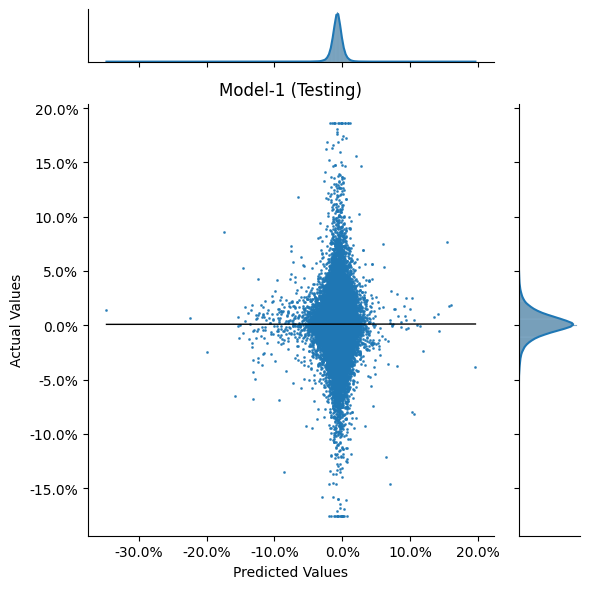

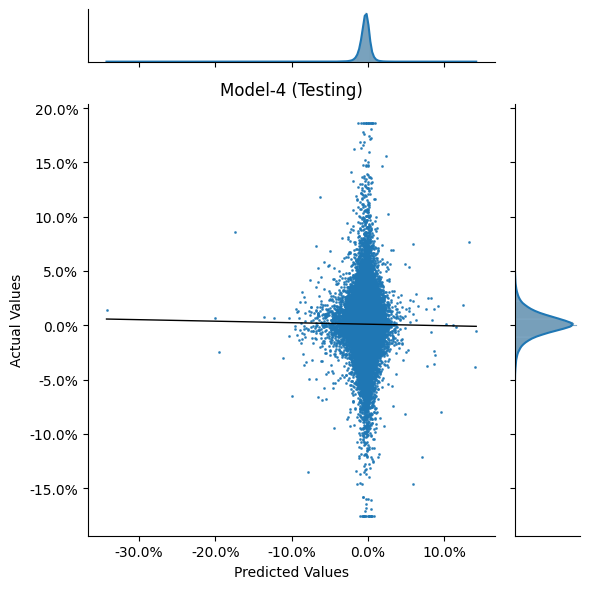

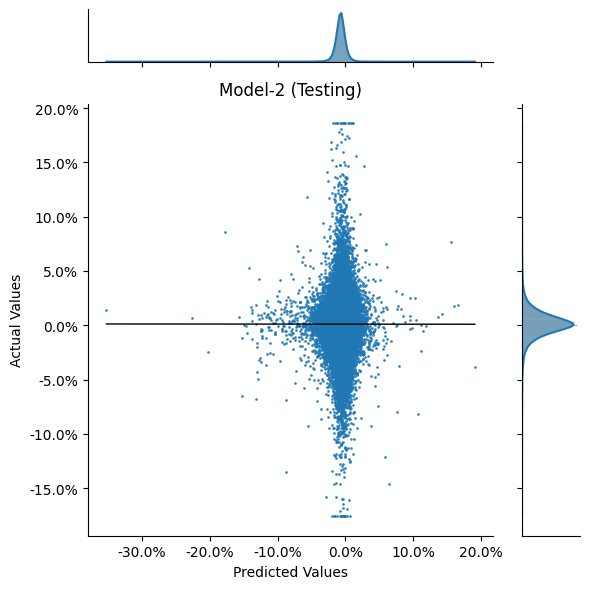

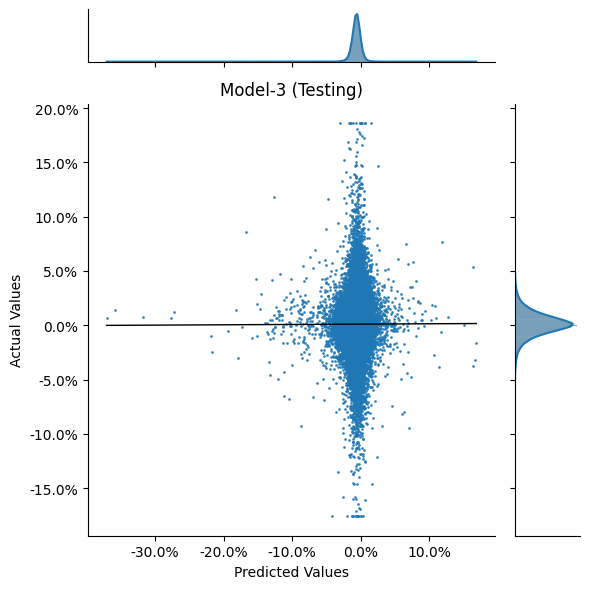

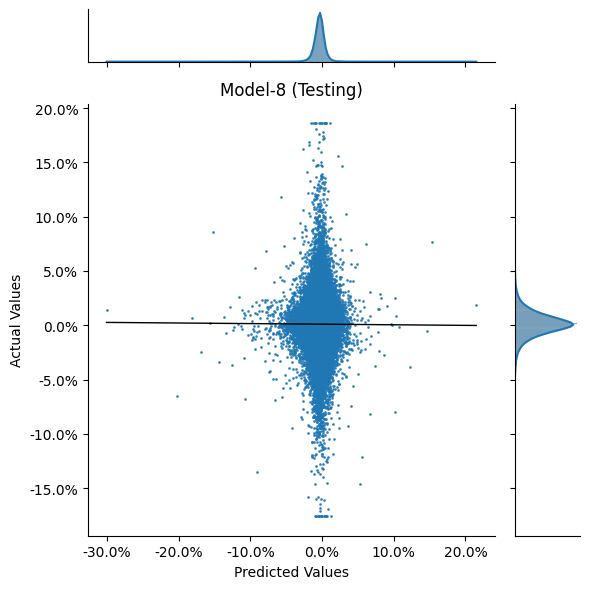

In [81]:
for model,pred in zip(models,test_predictions):
    j=sns.jointplot(
        x="ypreds",
        y="yreal",
        ci=None,
        robust=True,
        line_kws={"lw":1.0,"color":"k"},
        scatter_kws={"s":1.0},
        kind="reg",
        data=pred
    )

    j.ax_joint.yaxis.set_major_formatter(
        FuncFormatter(lambda y,_:'{:.1%}'.format(y))
    )

    j.ax_joint.xaxis.set_major_formatter(
        FuncFormatter(lambda x,_:'{:.1%}'.format(x))
    )

    j.ax_joint.set_xlabel("Predicted Values")
    j.ax_joint.set_ylabel("Actual Values")
    j.ax_joint.set_title(f"{model} (Testing)")

    plt.tight_layout()
    sns.despine()
    plt.show()

## Daily IC Distribution

In [82]:
test_scores=[
    model1_test_scores,
    model4_test_scores,
    model2_test_scores,
    model3_test_scores,
    model8_test_scores,
]

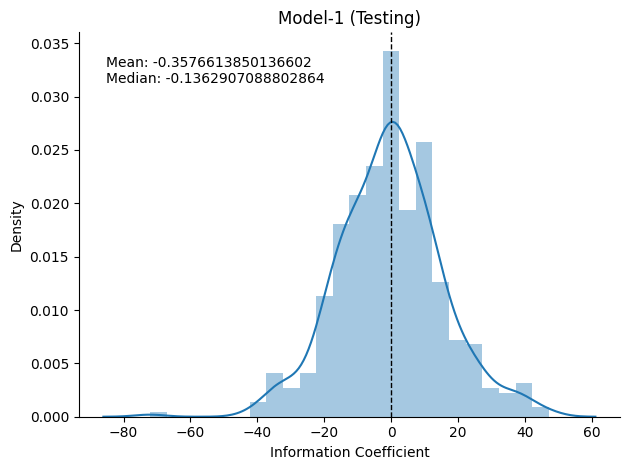

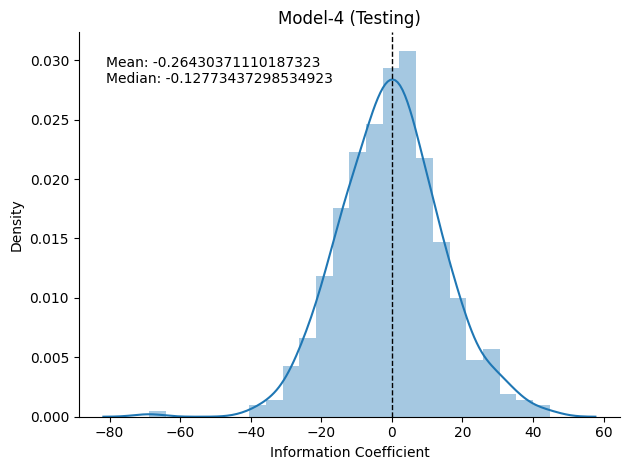

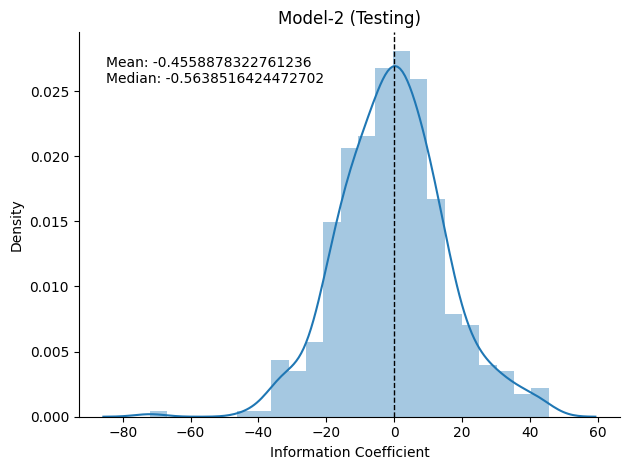

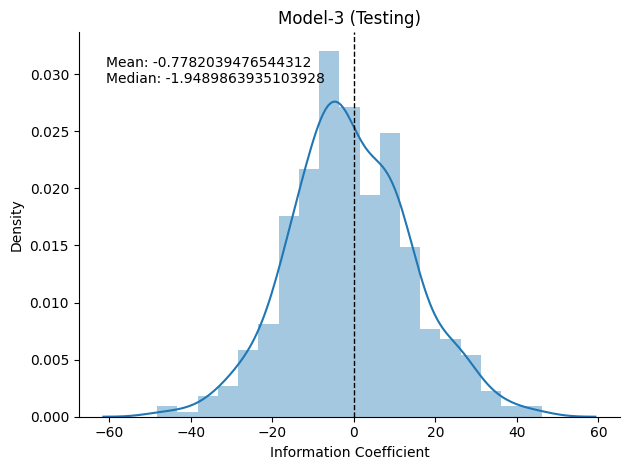

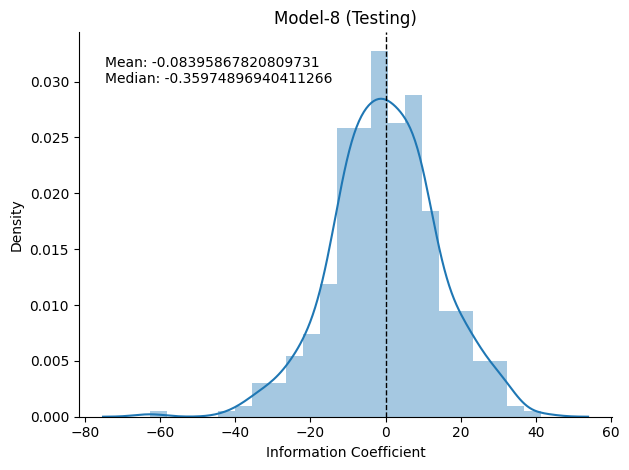

In [83]:
for model,score in zip(models,test_scores):
    ax=sns.distplot(score.ic)
    ax.axvline(0,lw=1.0,ls="--",c="k")

    ic_mean=score.ic.mean()
    ic_median=score.ic.median()

    ax.text(
        x=.05,
        y=.9,
        s=f"Mean: {ic_mean}\nMedian: {ic_median}",
        horizontalalignment="left",
        verticalalignment="center",
        transform=ax.transAxes
    )

    ax.set_xlabel("Information Coefficient")
    ax.set_title(f"{model} (Testing)")

    plt.tight_layout()
    sns.despine()
    plt.show()

## Rolling Daily IC

for model,score in zip(models,test_scores):
    score[["ic"]].rolling(21).mean().plot(figsize=(10,5))
    ic_mean=score.ic.mean(axis=0)
    plt.axhline(0,lw=.5,ls="-",c="k")
    plt.axhline(ic_mean,lw=1.0,ls="--",c="k",label="IC Mean")
    plt.legend()
    plt.ylabel("IC")
    plt.title(f"{model} (Testing)")
    
    plt.tight_layout()
    plt.show()

## Rolling RMSE

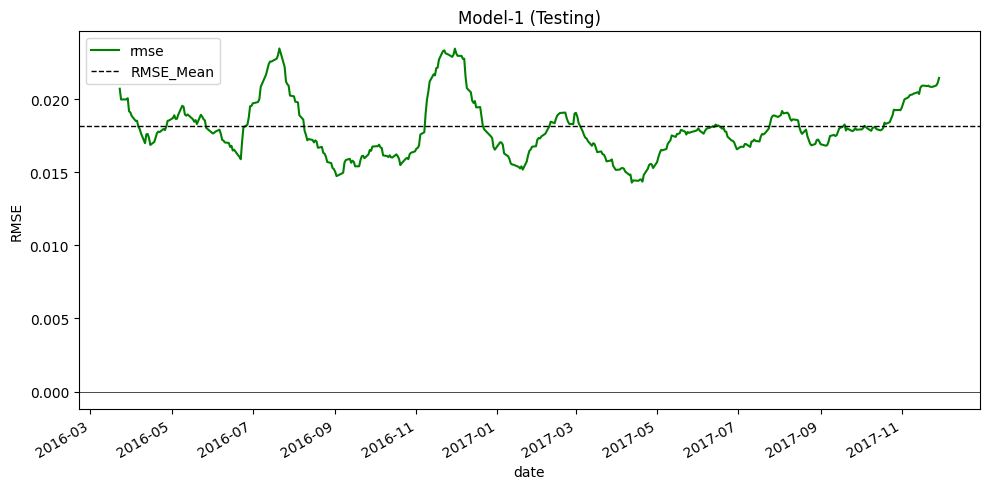

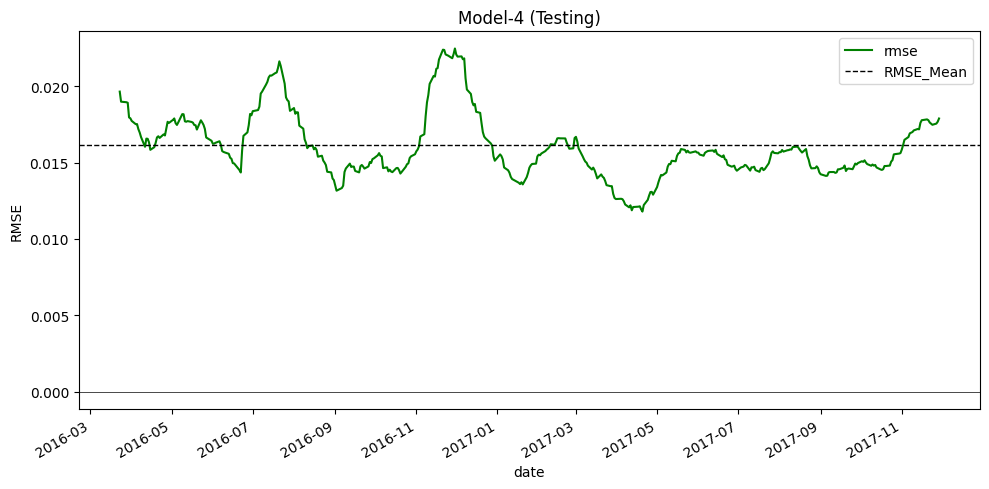

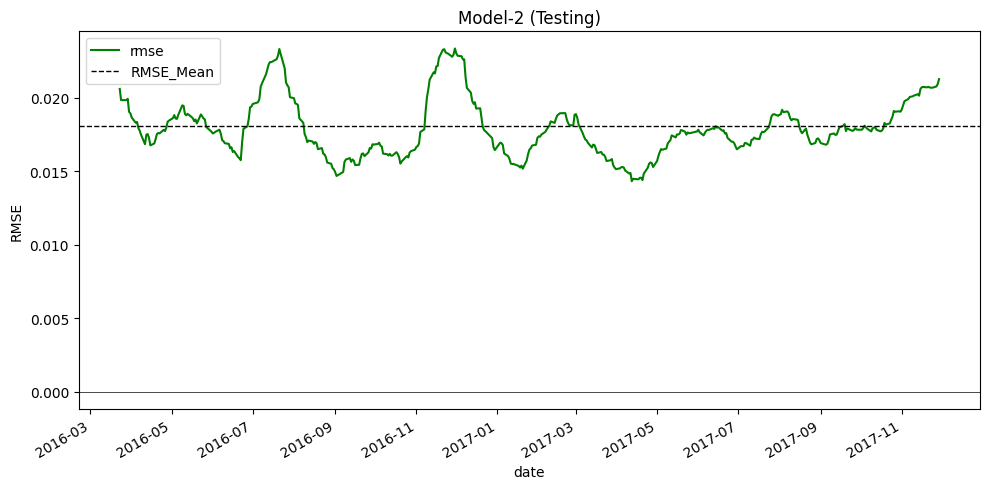

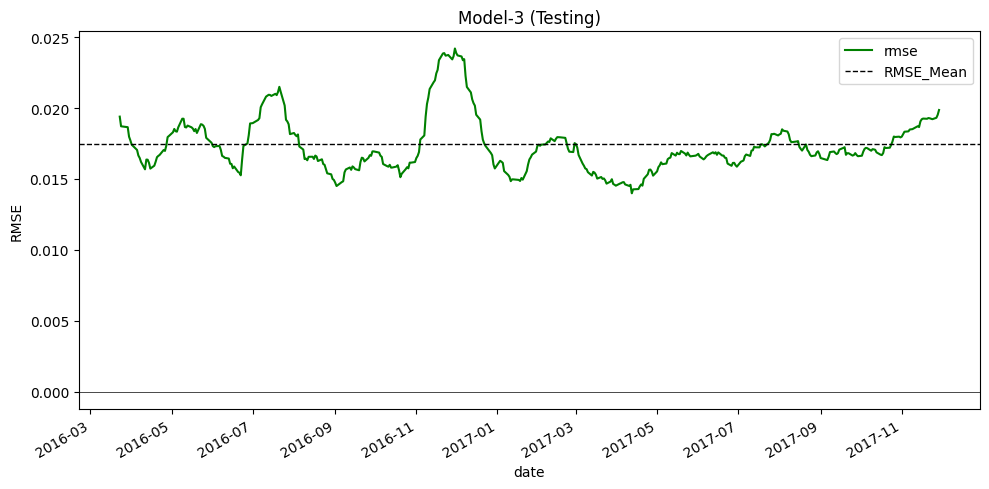

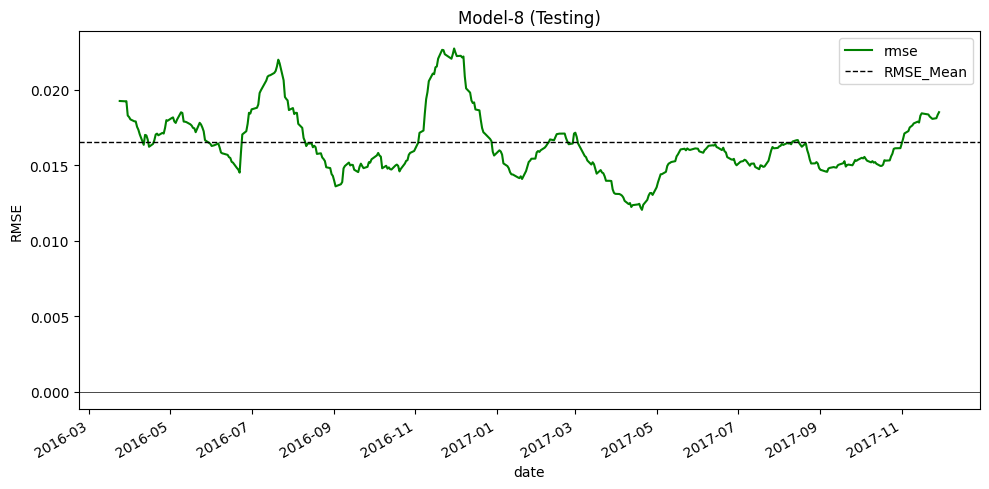

In [85]:
for model,score in zip(models,test_scores):
    score[["rmse"]].rolling(21).mean().plot(figsize=(10,5),style=["g"])

    rmse_mean=score.rmse.mean(axis=0)
    plt.axhline(0,lw=.5,ls="-",c="k")
    plt.axhline(rmse_mean,lw=1.0,ls="--",c="k",label="RMSE_Mean")
    plt.legend()
    plt.ylabel("RMSE")
    plt.title(f"{model} (Testing)")

    plt.tight_layout()
    plt.show()

# Comparing Training and Testing Plots

## Rolling IC Distribution

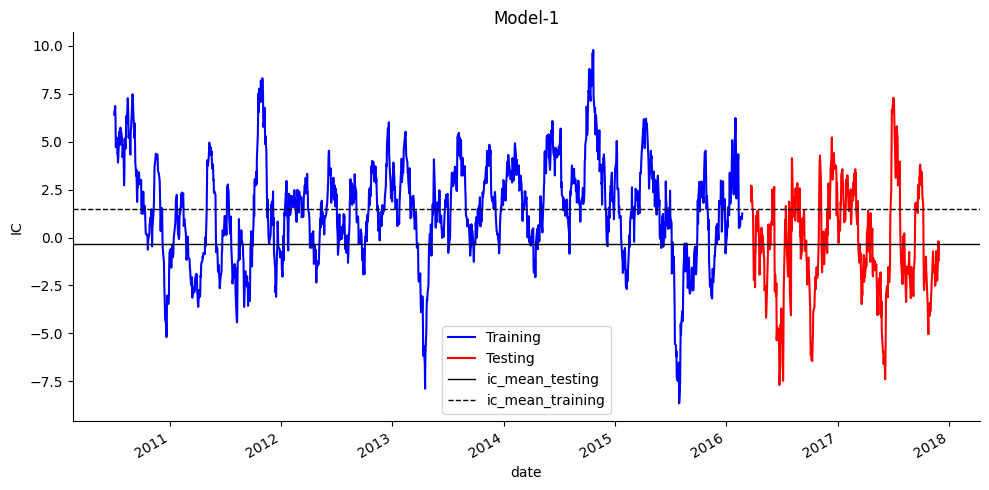

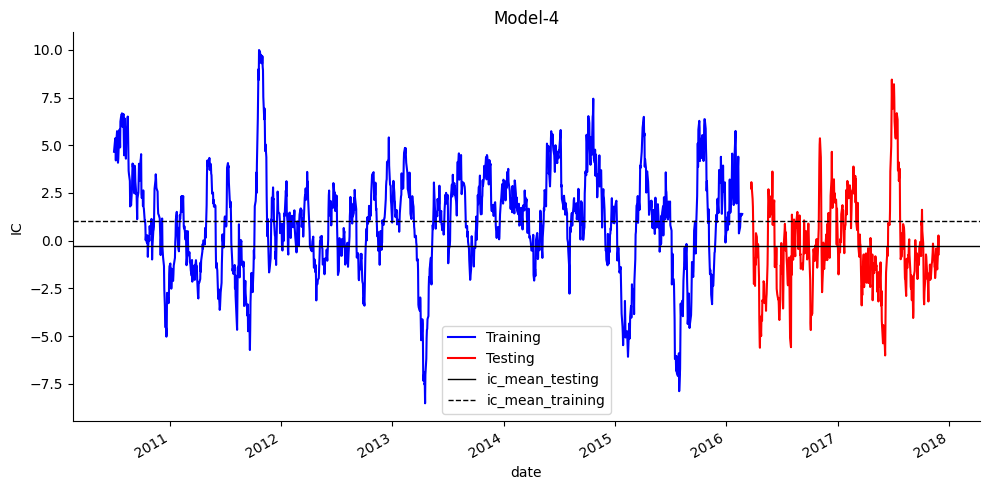

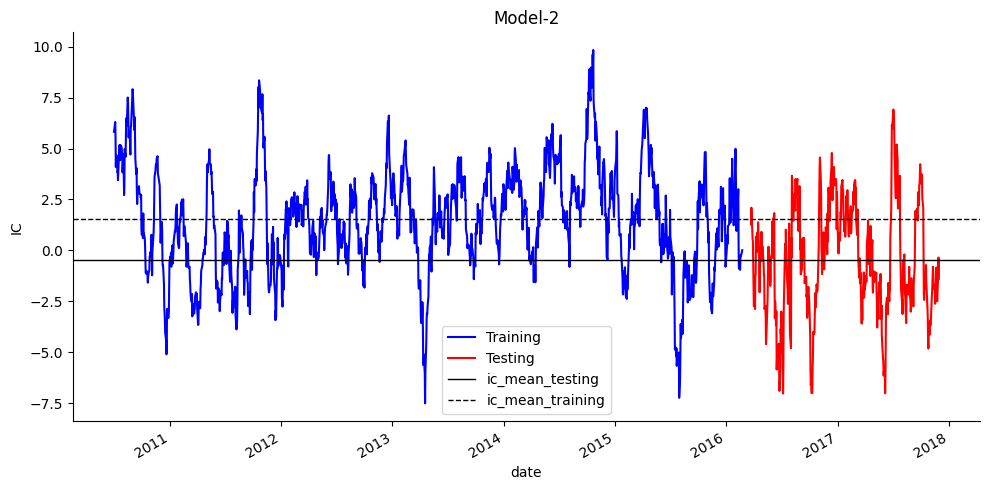

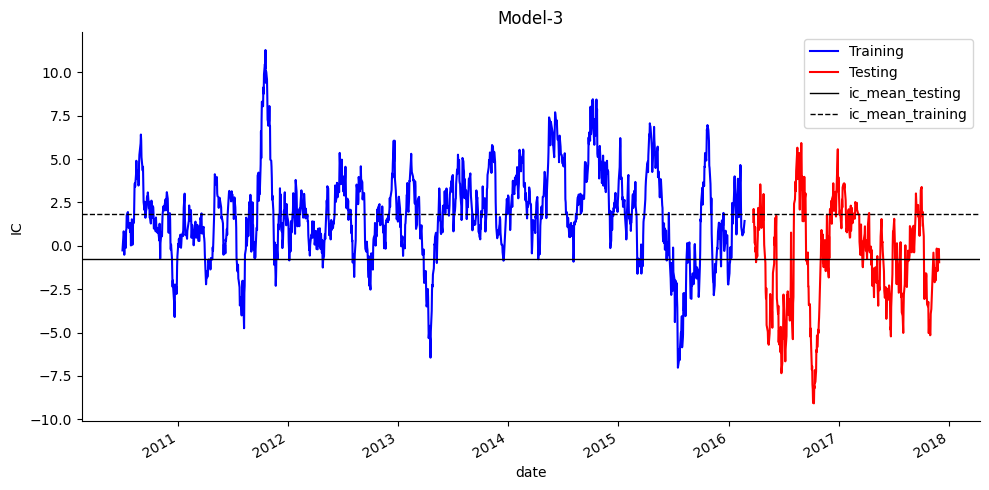

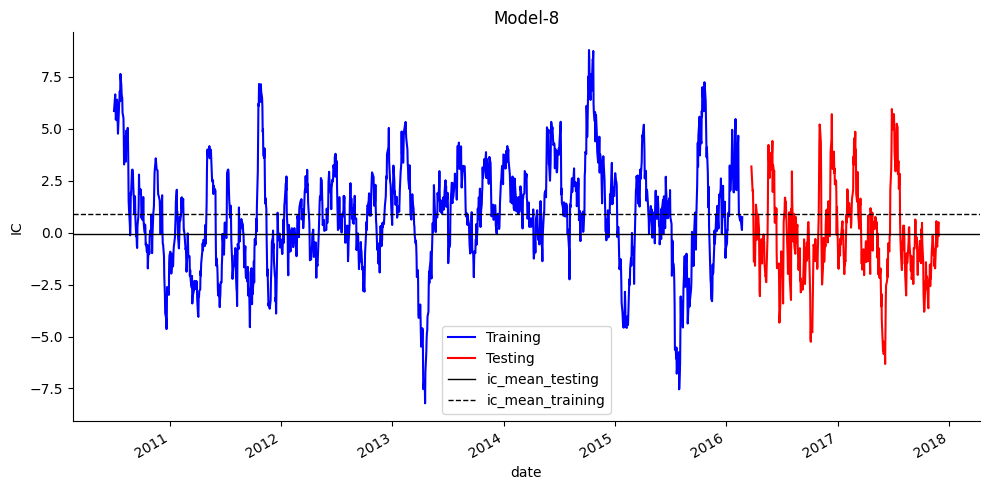

In [93]:
for model,train_score,test_score in zip(models,scores,test_scores):
    fig,ax=plt.subplots(figsize=(10,5))
    
    train_score["ic"].rolling(21).mean().plot(
        ax=ax,
        style=["b"],
        label="Training"
    )

    test_score["ic"].rolling(21).mean().plot(
        ax=ax,
        style=["r"],
        label="Testing"
    )

    ic_mean_train=train_score.ic.mean(axis=0)
    ic_mean_test=test_score.ic.mean(axis=0)

    ax.axhline(ic_mean_test,lw=1.0,ls="-",c="k",label="ic_mean_testing")
    ax.axhline(ic_mean_train,lw=1.0,ls="--",c="k",label="ic_mean_training")

    ax.set_ylabel("IC")
    ax.set_title(f"{model}")
    ax.legend()

    plt.tight_layout()
    sns.despine()
    plt.show()



## Rolling RMSE

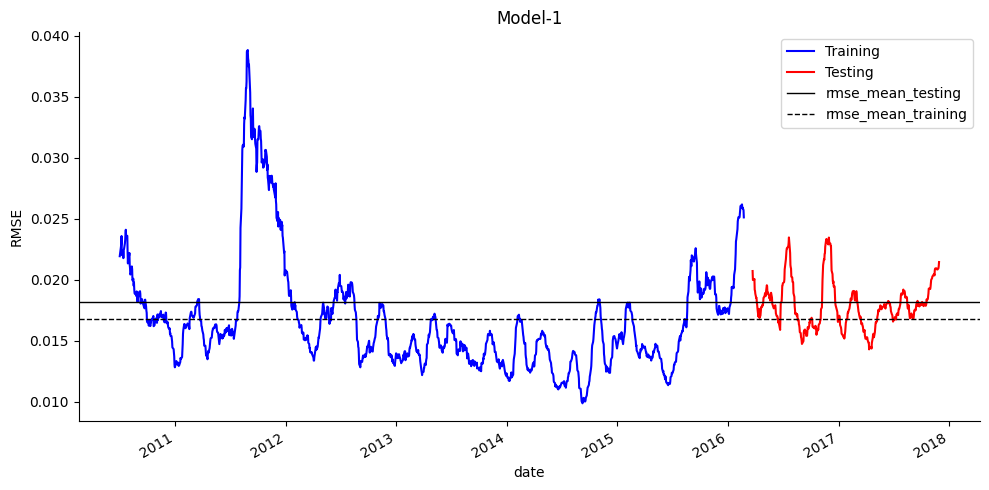

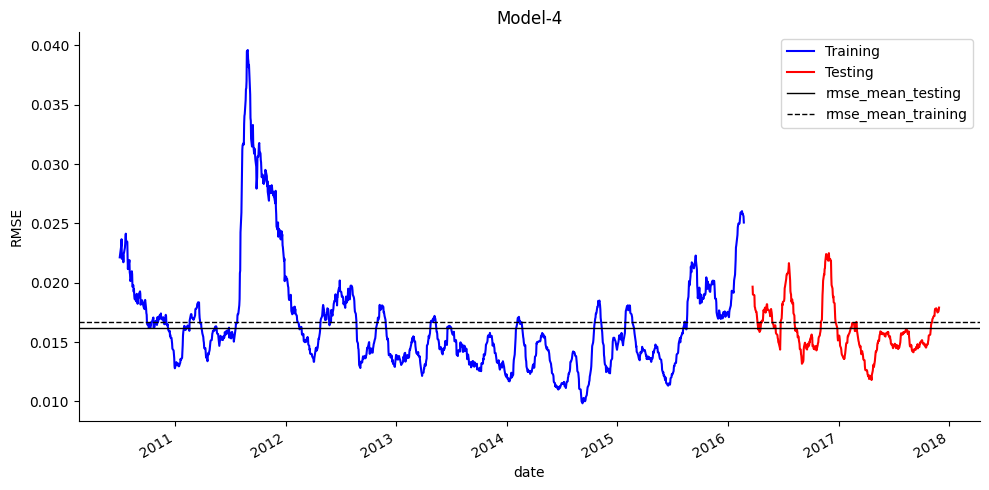

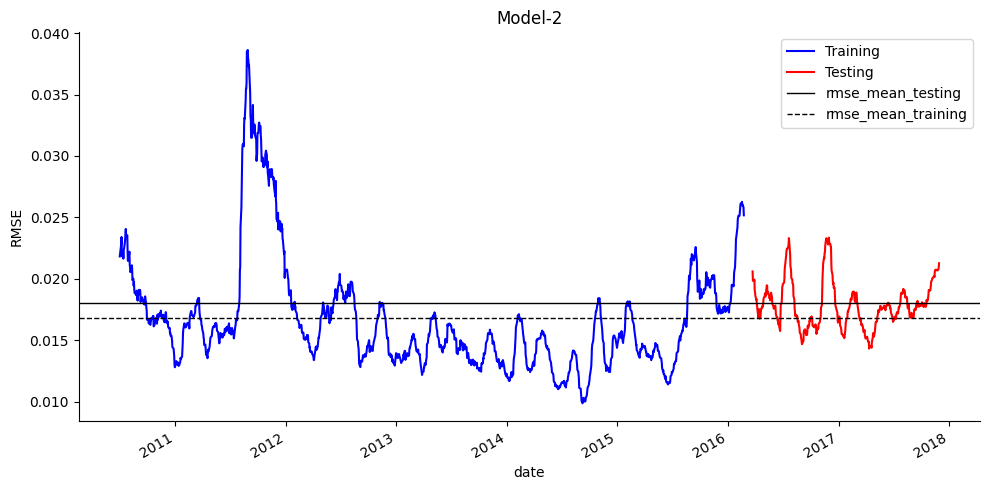

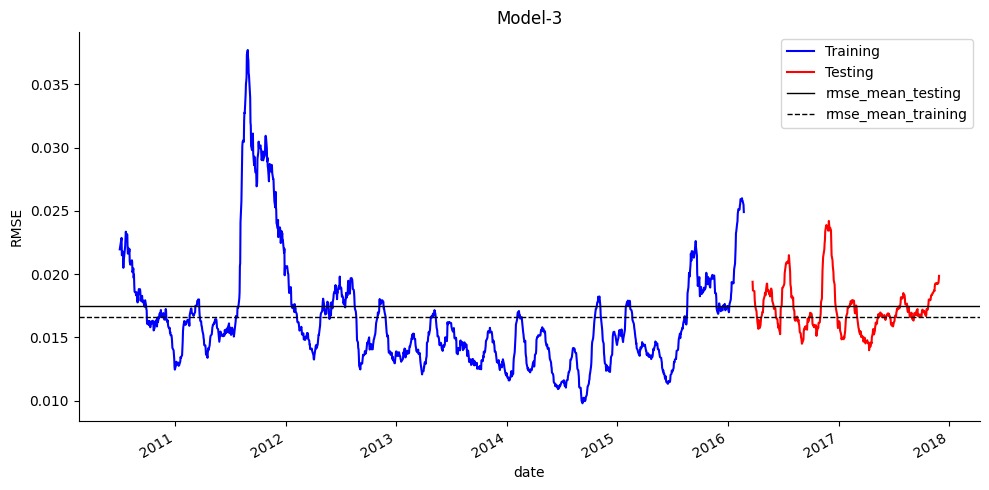

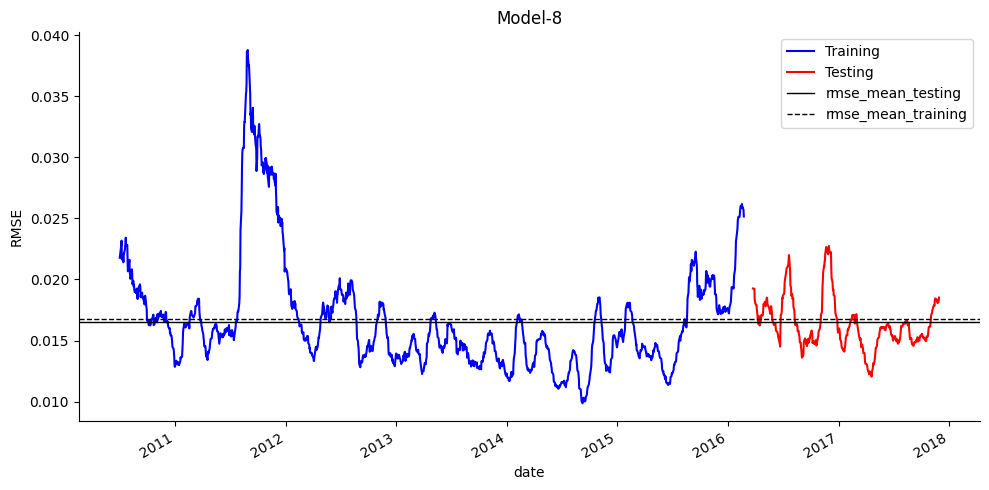

In [94]:
for model,train_score,test_score in zip(models,scores,test_scores):
    fig,ax=plt.subplots(figsize=(10,5))
    
    train_score["rmse"].rolling(21).mean().plot(
        ax=ax,
        style=["b"],
        label="Training"
    )

    test_score["rmse"].rolling(21).mean().plot(
        ax=ax,
        style=["r"],
        label="Testing"
    )

    rmse_mean_train=train_score.rmse.mean(axis=0)
    rmse_mean_test=test_score.rmse.mean(axis=0)

    ax.axhline(rmse_mean_test,lw=1.0,ls="-",c="k",label="rmse_mean_testing")
    ax.axhline(rmse_mean_train,lw=1.0,ls="--",c="k",label="rmse_mean_training")

    ax.set_ylabel("RMSE")
    ax.set_title(f"{model}")
    ax.legend()

    plt.tight_layout()
    sns.despine()
    plt.show()

